In [1]:
#output bifurcation diagram Fig3D

import os
import sys

sys.path.append('../')
sys.path.append('../anmodel')
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl

import anmodel
import numpy as np
import pandas as pd
import pickle
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize # Normalizeをimport

OK
OK


In [5]:

date_i = "2023_12_6_7_10"
bifur="_pre"
# date_i = "2023_3_27_1_5"
# bifur="_cav"
# date_i = "2023_4_26_0_2"
# bifur="_nmdar"


g_str = "g"+bifur
model_pre="AN"
N=80

T  =10000  #ms

rdir = "../AN_network/"
cc_dir = rdir + "/cc_dir/"
model=model_pre+"_log_noinin"+bifur
ex_file=date_i + "_NE64_NI16_conM1.0_SD0.01_conMin1.0_inSD0.01_T{}_cc.xlsx".format(T)


df_cc=pd.read_excel(cc_dir+model+"/"+ex_file, engine="openpyxl", index_col=0)

exs_str=df_cc["exp"]
exs = [float(i) for i in exs_str]



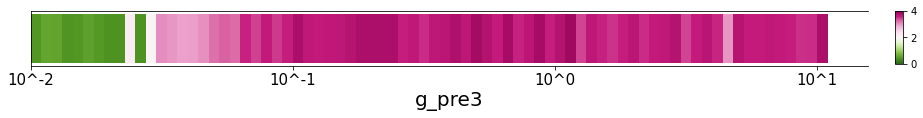

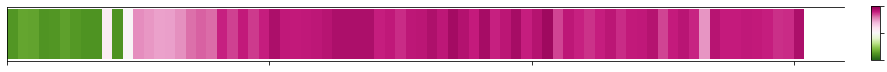

In [6]:
import matplotlib.cm as cm
import matplotlib as mpl

fs=20
fs_l=15



cvs=df_cc["cv"]

vmin = 0 
vmax= 4 #300 #np.max(cvs)

x="CV"

bottom  = 0
block=10

fig, ax = plt.subplots(figsize=(15,1))

ax.set_xticks([0, 200, 400, 600, 800])  
if g_str == "g_pre": 
    ax.set_xticks([0, 250, 500, 750])  

cmap = cm.get_cmap('PiYG_r')#('PuRd')
sm = cm.ScalarMappable(cmap=cmap,norm=Normalize(vmin=vmin, vmax=vmax)) #colormapを指定
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = True
plt.rcParams["axes.spines.left"] = True
plt.rcParams["axes.spines.bottom"] = True

for n,cv in enumerate(cvs):
    sca=ax.barh(x, block, left = bottom, color= cmap(cv/vmax))
    bottom +=block
    
# cax = fig.add_axes((0.125, 1.0, 0.737, 0.12)) #(hori move, ver move, hori long, ver thick)
# cbar = fig.colorbar(sm, aspect=30,orientation='horizontal', cax=cax)
# cbar.ax.set_xlim(0, vmax)
# cbar.ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(150))
# cbar.ax.xaxis.set_ticks_position('top')
cax = fig.add_axes((0.925, 0.15, 0.008, 0.737)) #(hori move, ver move, hori long, ver thick)
cbar = fig.colorbar(sm,orientation='vertical',cax=cax)
cbar.ax.set_ylim(0, vmax)
# cbar.ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(100))
cbar.ax.yaxis.set_ticks_position('right')
cbar.ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator((vmax/2)))


if g_str == "g_pre": 
    ax.set_xticklabels(["10^-2", "10^-1", "10^0", "10^1"],fontsize = fs_l)
else:
    ax.set_xticklabels(["10^-2", "10^-1", "10^0", "10^1", "10^2"],fontsize = fs_l)

ax.set_xlabel(g_str,fontsize = fs)
# ax.set_title("CV",fontsize = fs)
ax.tick_params(labelleft=False, left=False)
# plt.tight_layout()
plt.show()


#article
fig, ax = plt.subplots(figsize=(15,1))
ax.set_xticks([0, 200, 400, 600, 800])  
if g_str == "g_pre": 
    ax.set_xticks([0, 250, 500, 750])  
# cmap = cm.get_cmap('PuRd')
sm = cm.ScalarMappable(cmap=cmap,norm=Normalize(vmin=vmin, vmax=vmax)) #colormapを指定
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = True
plt.rcParams["axes.spines.left"] = True
plt.rcParams["axes.spines.bottom"] = True
bottom=0
for n,cv in enumerate(cvs):
    sca=ax.barh(x, block, left = bottom, color= cmap(cv/vmax))
    bottom +=block
    
# cax = fig.add_axes((0.125, 1.0, 0.737, 0.12)) #(hori move, ver move, hori long, ver thick)
# # cbar = fig.colorbar(sm, aspect=30,orientation='horizontal', cax=cax)
# cbar = fig.colorbar(sm, aspect=30,orientation='horizontal', cax=cax)
# cbar.ax.set_xlim(0, vmax)
# cbar.ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(150))
# cbar.ax.xaxis.set_ticks_position('top')
cax = fig.add_axes((0.925, 0.15, 0.008, 0.737)) #(hori move, ver move, hori long, ver thick)
cbar = fig.colorbar(sm,orientation='vertical',cax=cax)
cbar.ax.set_ylim(0, vmax)
# cbar.ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(100))
cbar.ax.yaxis.set_ticks_position('right')
cbar.ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator((vmax/2)))
cbar.ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:.1f}"))

ax.set_xlabel("",fontsize = fs)
ax.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False, left=False,)
ax2 = plt.gca()
ax2.axes.xaxis.set_ticklabels([])
ax2.axes.yaxis.set_ticklabels([])

plt.savefig("bifur_diagram_{}_{}_N{}_cv_RG.SVG".format(date_i, g_str, N))


plt.show()

56.34

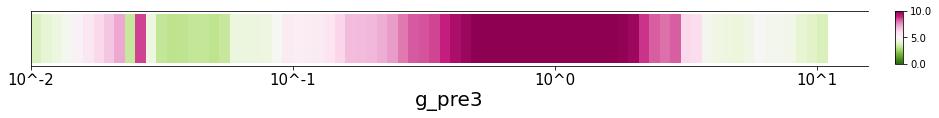

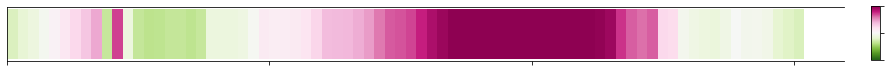

In [7]:
cvs=df_cc["mean_spike_fre"]

vmin = 0.0
vmax=10.0 

x="CV"

bottom  = 0
block=10

fig, ax = plt.subplots(figsize=(15,1))

ax.set_xticks([0, 200, 400, 600, 800])  
if g_str == "g_pre": 
    ax.set_xticks([0, 250, 500, 750])  
cmap = cm.get_cmap('PiYG_r')#('PuRd')
sm = cm.ScalarMappable(cmap=cmap,norm=Normalize(vmin=vmin, vmax=vmax)) #colormapを指定
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = True
plt.rcParams["axes.spines.left"] = True
plt.rcParams["axes.spines.bottom"] = True

for n,cv in enumerate(cvs):
    sca=ax.barh(x, block, left = bottom, color= cmap(cv/vmax))
    bottom +=block
    
# cax = fig.add_axes((0.125, 1.0, 0.737, 0.12)) #(hori move, ver move, hori long, ver thick)
# cbar = fig.colorbar(sm, aspect=30,orientation='horizontal', cax=cax)
# cbar.ax.set_xlim(0, vmax)
# cbar.ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(100))
# cbar.ax.xaxis.set_ticks_position('top')
# cbar.ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(5.0))
# cbar.ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:.1f}"))
cax = fig.add_axes((0.925, 0.15, 0.008, 0.737)) #(hori move, ver move, hori long, ver thick)
cbar = fig.colorbar(sm,orientation='vertical',cax=cax)
cbar.ax.set_ylim(0, vmax)
cbar.ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(100))
cbar.ax.yaxis.set_ticks_position('right')
cbar.ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(int(vmax/2)))
cbar.ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:.1f}"))

if g_str == "g_pre": 
    ax.set_xticklabels(["10^-2", "10^-1", "10^0", "10^1"],fontsize = fs_l)
else:
    ax.set_xticklabels(["10^-2", "10^-1", "10^0", "10^1", "10^2"],fontsize = fs_l)
ax.set_xlabel(g_str,fontsize = fs)
# ax.set_title("sp_fre",fontsize = fs)
ax.tick_params(labelleft=False, left=False)

plt.show()


#article
fig, ax = plt.subplots(figsize=(15,1))

ax.set_xticks([0, 200, 400, 600, 800])  
if g_str == "g_pre": 
    ax.set_xticks([0, 250, 500, 750])  

sm = cm.ScalarMappable(cmap=cmap,norm=Normalize(vmin=vmin, vmax=vmax)) #colormapを指定
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = True
plt.rcParams["axes.spines.left"] = True
plt.rcParams["axes.spines.bottom"] = True
bottom=0
for n,cv in enumerate(cvs):
    sca=ax.barh(x, block, left = bottom, color= cmap(cv/vmax))
    bottom +=block
    
# cax = fig.add_axes((0.125, 1.0, 0.737, 0.12)) #(hori move, ver move, hori long, ver thick)
# cbar = fig.colorbar(sm, aspect=30,orientation='horizontal', cax=cax)
# cbar = fig.colorbar(sm, aspect=30,orientation='horizontal', cax=cax)
# cbar.ax.set_xlim(0, vmax)
# cbar.ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(100))
# cbar.ax.xaxis.set_ticks_position('top')
# cbar.ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(5.0))
# cbar.ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:.1f}"))
cax = fig.add_axes((0.925, 0.15, 0.008, 0.737)) #(hori move, ver move, hori long, ver thick)
cbar = fig.colorbar(sm,orientation='vertical',cax=cax)
cbar.ax.set_ylim(0, vmax)
cbar.ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(100))
cbar.ax.yaxis.set_ticks_position('right')
cbar.ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(int(vmax/2)))
cbar.ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:.1f}"))
ax.set_xlabel("",fontsize = fs)
ax.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False, left=False,)
ax2 = plt.gca()
ax2.axes.xaxis.set_ticklabels([])
ax2.axes.yaxis.set_ticklabels([])

plt.savefig("bifur_diagram_{}_{}_N{}_fre_10_RG.SVG".format(date_i, g_str,N))


plt.show()

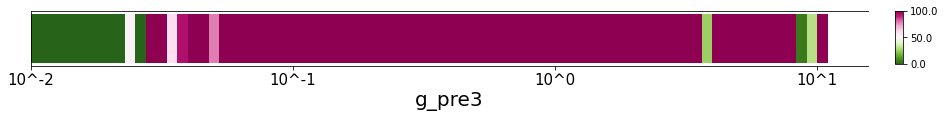

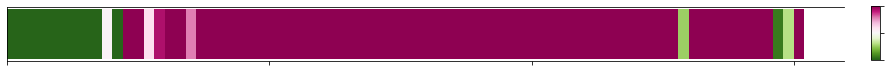

In [8]:
# cvs=df_cc["mean_spike_fre"]
cvs =  df_cc["%sleep"]



vmin = 0
vmax=100.0

x=g_str


bottom  = 0
block=10

fig, ax = plt.subplots(figsize=(15,1))

ax.set_xticks([0, 200, 400, 600, 800])  
if g_str == "g_pre": 
    ax.set_xticks([0, 250, 500, 750])  
    
cmap = cm.get_cmap('PiYG_r')#('PuRd')
sm = cm.ScalarMappable(cmap=cmap,norm=Normalize(vmin=vmin, vmax=vmax)) #colormapを指定
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = True
plt.rcParams["axes.spines.left"] = True
plt.rcParams["axes.spines.bottom"] = True

for n,cv in enumerate(cvs):
    sca=ax.barh(x, block, left = bottom, color= cmap(cv/vmax))
    bottom +=block
    
# cax = fig.add_axes((0.125, 1.0, 0.737, 0.12)) #(hori move, ver move, hori long, ver thick)

# cbar = fig.colorbar(sm, aspect=30,orientation='horizontal', cax=cax)
# cbar.ax.set_xlim(0, vmax)
# cbar.ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(100))
# cbar.ax.xaxis.set_ticks_position('top')
# cbar.ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(50.0))
# cbar.ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:.1f}"))
# cbar.ax.yaxis.label.set_size(15)
# cbar.ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:.1f}"))
cax = fig.add_axes((0.925, 0.15, 0.008, 0.737)) #(hori move, ver move, hori long, ver thick)
cbar = fig.colorbar(sm,orientation='vertical',cax=cax)
cbar.ax.set_ylim(0, vmax)
cbar.ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(100))
cbar.ax.yaxis.set_ticks_position('right')
cbar.ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(vmax/2))
cbar.ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:.1f}"))

if g_str == "g_pre": 
    ax.set_xticklabels(["10^-2", "10^-1", "10^0", "10^1"],fontsize = fs_l)
else:
    ax.set_xticklabels(["10^-2", "10^-1", "10^0", "10^1", "10^2"],fontsize = fs_l)
ax.set_xlabel(g_str,fontsize = fs)
# ax.set_ylabel(x,fontsize = fs, rotation=0)
ax.tick_params(labelleft=False, left=False)

plt.show()


#article
fig, ax = plt.subplots(figsize=(15,1))

ax.set_xticks([0, 200, 400, 600, 800])  
if g_str == "g_pre": 
    ax.set_xticks([0, 250, 500, 750])  

sm = cm.ScalarMappable(cmap=cmap,norm=Normalize(vmin=vmin, vmax=vmax)) #colormapを指定
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = True
plt.rcParams["axes.spines.left"] = True
plt.rcParams["axes.spines.bottom"] = True
bottom=0
for n,cv in enumerate(cvs):
    sca=ax.barh(x, block, left = bottom, color= cmap(cv/vmax))
    if n<=len(cvs)-1:
        bottom +=block
    
cax = fig.add_axes((0.925, 0.15, 0.008, 0.737)) #(hori move, ver move, hori long, ver thick)
cbar = fig.colorbar(sm,orientation='vertical',cax=cax)
cbar.ax.set_ylim(0, vmax)
cbar.ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(100))
cbar.ax.yaxis.set_ticks_position('right')
cbar.ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(50.0))
cbar.ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:.1f}"))
ax.set_xlabel("",fontsize = fs)
ax.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False, left=False,)
ax2 = plt.gca()
ax2.axes.xaxis.set_ticklabels([])
ax2.axes.yaxis.set_ticklabels([])

plt.savefig("bifur_diagram_{}_{}_N{}_sleep_RG.SVG".format(date_i, g_str,N))
# 

plt.show()
